# Random Forest v2 — Preprocessing enrichi

## Contexte

Ce notebook reprend la modélisation **Random Forest** avec un **preprocessing enrichi** basé sur l'analyse des colonnes écartées lors du premier prétraitement.

### Améliorations par rapport à `RandomForest_model.ipynb`

| Aspect | v1 (ancien) | v2 (ce notebook) |
|---|---|---|
| **Colonnes utilisées** | 14 sur 45 | 26 sur 45 |
| **OrgId / DetectorId** | Écartées | Frequency encoding |
| **AlertTitle** | Écartée | Top 100 + Other |
| **RegistryKey/ValueName** | Écartées | OHE (55 + 28 valeurs) |
| **ApplicationId/Name** | Écartées | OHE / Top 50 |
| **OAuthApplicationId** | Écartée | OHE (21 valeurs) |
| **ResourceIdName** | Écartée | OHE (58 valeurs) |
| **DeviceId** | Écartée | Frequency encoding |
| **FileName** | Écartée | Extension extraction |
| **FolderPath** | Écartée | Root folder extraction |
| **Features d'agrégation** | Aucune | Nb alertes/incident, nb entités/incident |

### Justification (article Microsoft)

Freitas et al. (2024) — *"AI-Driven Guided Response for SOCs with Microsoft Copilot for Security"* (arXiv:2407.09017) — montrent que **OrgId** et **DetectorId** sont des features critiques dans leur Random Forest de production (Macro F1 = 0.87).

### Objectif

Passer de **Macro F1 = 0.605** (v1) à un score significativement meilleur grâce à l'enrichissement des features.

## 1. Importation des bibliothèques

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

CIBLE_MAP = {'BenignPositive': 0, 'FalsePositive': 1, 'TruePositive': 2}
CIBLE_MAP_INV = {v: k for k, v in CIBLE_MAP.items()}

print("Bibliothèques importées avec succès.")

 Bibliothèques importées avec succès.


## 2. Chargement et preprocessing enrichi

On charge directement `echantillon.csv` (dataset brut, 45 colonnes) et on applique un preprocessing enrichi qui récupère les colonnes à forte valeur prédictive identifiées lors de l'analyse.

In [ ]:
# ============================================================
# 2.1 Chargement du dataset brut
# ============================================================
raw = pd.read_csv('echantillon.csv', low_memory=False)
print(f"Dataset brut : {raw.shape[0]:,} lignes x {raw.shape[1]} colonnes")

df = raw.copy()

# ============================================================
# 2.2 Traitement du Timestamp -> features temporelles
# ============================================================
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Hour']       = df['Timestamp'].dt.hour
df['DayOfWeek']  = df['Timestamp'].dt.dayofweek
df['DayOfMonth'] = df['Timestamp'].dt.day
df['Month']      = df['Timestamp'].dt.month
df['IsWeekend']      = (df['DayOfWeek'] >= 5).astype(int)
df['IsBusinessHour'] = df['Hour'].between(8, 18).astype(int)
df.drop(columns=['Timestamp'], inplace=True)
print("[OK] Features temporelles creees : Hour, DayOfWeek, DayOfMonth, Month, IsWeekend, IsBusinessHour")

# ============================================================
# 2.3 Frequency Encoding pour colonnes haute cardinalité
# (OrgId, DetectorId, DeviceId — features critiques selon Microsoft)
# ============================================================
for col in ['OrgId', 'DetectorId', 'DeviceId']:
    freq = df[col].value_counts(normalize=True)
    df[f'{col}_freq'] = df[col].map(freq).astype(float)
    df.drop(columns=[col], inplace=True)
print("[OK] Frequency encoding : OrgId_freq, DetectorId_freq, DeviceId_freq")

# ============================================================
# 2.4 AlertTitle -> Top 100 + Other
# ============================================================
top_alerts = df['AlertTitle'].value_counts().head(100).index
df['AlertTitle_group'] = df['AlertTitle'].where(df['AlertTitle'].isin(top_alerts), other='Other')
df.drop(columns=['AlertTitle'], inplace=True)
print(f"[OK] AlertTitle -> AlertTitle_group ({df['AlertTitle_group'].nunique()} categories)")

# ============================================================
# 2.5 FileName -> extraction d'extension de fichier
# ============================================================
# Les valeurs sont encodées en int dans ce dataset, on extrait les fréquences
top_files = df['FileName'].value_counts().head(50).index
df['FileName_group'] = df['FileName'].where(df['FileName'].isin(top_files), other=-1)
df['FileName_group'] = df['FileName_group'].astype(str)
df.drop(columns=['FileName'], inplace=True)
print(f"[OK] FileName -> FileName_group ({df['FileName_group'].nunique()} categories)")

# ============================================================
# 2.6 FolderPath -> Top 50 + Other
# ============================================================
top_folders = df['FolderPath'].value_counts().head(50).index
df['FolderPath_group'] = df['FolderPath'].where(df['FolderPath'].isin(top_folders), other=-1)
df['FolderPath_group'] = df['FolderPath_group'].astype(str)
df.drop(columns=['FolderPath'], inplace=True)
print(f"[OK] FolderPath -> FolderPath_group ({df['FolderPath_group'].nunique()} categories)")

# ============================================================
# 2.7 MitreTechniques -> extraction technique principale + Top 15
# ============================================================
df['MitreTechniques'] = df['MitreTechniques'].fillna('Unknown')
df['MitreTechnique_Main'] = df['MitreTechniques'].apply(
    lambda x: x.split(';')[0].strip() if isinstance(x, str) and x != 'Unknown' else 'Unknown'
)
top_techniques = df['MitreTechnique_Main'].value_counts().head(15).index
df['MitreTechnique_Main'] = df['MitreTechnique_Main'].where(
    df['MitreTechnique_Main'].isin(top_techniques), other='Other'
)
df.drop(columns=['MitreTechniques'], inplace=True)
print(f"[OK] MitreTechniques -> MitreTechnique_Main ({df['MitreTechnique_Main'].nunique()} categories)")

# ============================================================
# 2.8 Traitement des NaN
# ============================================================
df['SuspicionLevel'] = df['SuspicionLevel'].fillna('None')
df['LastVerdict']    = df['LastVerdict'].fillna('Unknown')
df['OSVersion']      = df['OSVersion'].fillna('Unknown')
df['OSFamily']       = df['OSFamily'].fillna('Unknown')
print("[OK] NaN traites : SuspicionLevel->'None', LastVerdict->'Unknown', OSVersion/OSFamily->'Unknown'")

# ============================================================
# 2.9 Réduction de cardinalité pour colonnes géographiques
# ============================================================
def reduire_cardinalite(series, top_n=20, fill='Other'):
    top_vals = series.value_counts().head(top_n).index
    return series.where(series.isin(top_vals), other=fill)

df['City']        = reduire_cardinalite(df['City'], top_n=20)
df['State']       = reduire_cardinalite(df['State'], top_n=20)
df['CountryCode'] = reduire_cardinalite(df['CountryCode'], top_n=30)
df['OSVersion']   = reduire_cardinalite(df['OSVersion'], top_n=15)
print("[OK] Reduction cardinalite : City(20), State(20), CountryCode(30), OSVersion(15)")

# ============================================================
# 2.10 Colonnes à faible cardinalité récupérées (OHE direct)
# ============================================================
# RegistryKey (55), RegistryValueName (28), ApplicationId (68),
# OAuthApplicationId (21), ResourceIdName (58)
# -> on les garde telles quelles, elles seront OHE dans le pipeline

# ApplicationName (100 uniques) -> Top 50 + Other
top_apps = df['ApplicationName'].value_counts().head(50).index
df['ApplicationName'] = df['ApplicationName'].where(
    df['ApplicationName'].isin(top_apps), other='Other'
)
print(f"[OK] Colonnes faible cardinalite gardees : RegistryKey, RegistryValueName, ApplicationId, OAuthApplicationId, ResourceIdName")
print(f"   ApplicationName -> top 50 ({df['ApplicationName'].nunique()} categories)")

# ============================================================
# 2.11 Features d'agrégation par incident
# ============================================================
incident_stats = df.groupby('IncidentId').agg(
    nb_alertes=('AlertId', 'nunique'),
    nb_entites=('Id', 'nunique'),
    nb_types_entites=('EntityType', 'nunique'),
    nb_categories=('Category', 'nunique')
).reset_index()

df = df.merge(incident_stats, on='IncidentId', how='left')
print(f"[OK] Features d'agregation creees : nb_alertes, nb_entites, nb_types_entites, nb_categories")

# ============================================================
# 2.12 Suppression des colonnes identifiants purs et vides
# ============================================================
cols_to_drop = [
    'Id', 'IncidentId', 'AlertId',         # Identifiants purs
    'ActionGrouped', 'ActionGranular',       # 100% NaN
    'EmailClusterId',                        # 99% NaN
    'ThreatFamily',                          # 99.2% NaN
    'ResourceType',                          # 99.9% NaN
    'Roles',                                 # 97.6% NaN
    'AntispamDirection',                     # 98.1% NaN
    'Sha256', 'IpAddress', 'Url',           # Trop granulaires
    'AccountSid', 'AccountUpn',              # Identifiants utilisateurs
    'AccountObjectId', 'AccountName',        # Identifiants utilisateurs
    'DeviceName', 'NetworkMessageId',        # Identifiants nominaux
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print(f"[OK] Colonnes supprimees : {len(cols_to_drop)} (identifiants purs + NaN >97%)")

# ============================================================
# 2.13 Conversion des types pour le pipeline
# ============================================================
# Les colonnes int encodées doivent être converties en str pour OHE
int_to_cat = ['RegistryKey', 'RegistryValueName', 'RegistryValueData',
              'ApplicationId', 'OAuthApplicationId', 'ResourceIdName',
              'OSFamily', 'OSVersion', 'CountryCode', 'State', 'City']
for col in int_to_cat:
    if col in df.columns:
        df[col] = df[col].astype(str)

# AlertTitle_group est déjà int encodé dans le brut
df['AlertTitle_group'] = df['AlertTitle_group'].astype(str)
df['ApplicationName'] = df['ApplicationName'].astype(str)

print(f"\n{'='*60}")
print(f"DATASET ENRICHI : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"{'='*60}")
print(f"\nColonnes : {list(df.columns)}")

Dataset brut : 94,638 lignes × 45 colonnes
 Features temporelles créées : Hour, DayOfWeek, DayOfMonth, Month, IsWeekend, IsBusinessHour
 Frequency encoding : OrgId_freq, DetectorId_freq, DeviceId_freq
 AlertTitle → AlertTitle_group (101 catégories)
 FileName → FileName_group (51 catégories)
 FolderPath → FolderPath_group (51 catégories)
 MitreTechniques → MitreTechnique_Main (16 catégories)
 NaN traités : SuspicionLevel→'None', LastVerdict→'Unknown', OSVersion/OSFamily→'Unknown'
 Réduction cardinalité : City(20), State(20), CountryCode(30), OSVersion(15)
 Colonnes faible cardinalité gardées : RegistryKey, RegistryValueName, ApplicationId, OAuthApplicationId, ResourceIdName
   ApplicationName → top 50 (51 catégories)
 Features d'agrégation créées : nb_alertes, nb_entites, nb_types_entites, nb_categories
 Colonnes supprimées : 19 (identifiants purs + NaN >97%)

DATASET ENRICHI : 94,638 lignes × 35 colonnes

Colonnes : ['Category', 'IncidentGrade', 'EntityType', 'EvidenceRole', 'RegistryK

## 3. Préparation des données pour la modélisation

In [3]:
# ============================================================
# 3.1 Séparation features / cible
# ============================================================
y = df['IncidentGrade'].map(CIBLE_MAP)
X = df.drop(columns=['IncidentGrade'])

# ============================================================
# 3.2 Identifier colonnes numériques et catégorielles
# ============================================================
num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Features totales : {X.shape[1]}")
print(f"  Numeriques    ({len(num_cols)}) : {num_cols}")
print(f"  Categorielles ({len(cat_cols)}) : {cat_cols}")
print(f"\nDistribution cible :")
print(y.map(CIBLE_MAP_INV).value_counts().to_string())

# ============================================================
# 3.3 Split train/test (80/20 stratifié — même seed que v1)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2026
)
print(f"\nTrain : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

# ============================================================
# 3.4 Pipeline de preprocessing
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist',
                              sparse_output=False, min_frequency=10), cat_cols),
    ]
)

t0 = time.time()
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)
t_preprocess = time.time() - t0

print(f"\nTemps preprocessing : {t_preprocess:.1f}s")
print(f"Dimensionnalite apres OHE : {X_train_transformed.shape[1]} features")
print(f"Train : {X_train_transformed.shape}  |  Test : {X_test_transformed.shape}")
print(f"\nComparaison v1 vs v2 :")
print(f"   v1 : ~146 features")
print(f"   v2 : {X_train_transformed.shape[1]} features (+{X_train_transformed.shape[1] - 146})")

Features totales : 34
  Numériques    (13) : ['Hour', 'DayOfWeek', 'DayOfMonth', 'Month', 'IsWeekend', 'IsBusinessHour', 'OrgId_freq', 'DetectorId_freq', 'DeviceId_freq', 'nb_alertes', 'nb_entites', 'nb_types_entites', 'nb_categories']
  Catégorielles (21) : ['Category', 'EntityType', 'EvidenceRole', 'RegistryKey', 'RegistryValueName', 'RegistryValueData', 'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'ResourceIdName', 'OSFamily', 'OSVersion', 'SuspicionLevel', 'LastVerdict', 'CountryCode', 'State', 'City', 'AlertTitle_group', 'FileName_group', 'FolderPath_group', 'MitreTechnique_Main']

Distribution cible :
IncidentGrade
BenignPositive    41105
TruePositive      33220
FalsePositive     20313

Train : 75,710  |  Test : 18,928

 Temps preprocessing : 0.7s
Dimensionnalité après OHE : 356 features
Train : (75710, 356)  |  Test : (18928, 356)

 Comparaison v1 vs v2 :
   v1 : ~146 features
   v2 : 356 features (+210)

 Temps preprocessing : 0.7s
Dimensionnalité après OHE : 356 f

## 4. Random Forest — Modèle baseline

On entraîne d'abord un RF avec les mêmes hyperparamètres que la v1 pour isoler l'impact du preprocessing enrichi.

In [4]:
# ============================================================
# 4.1 RF Baseline (mêmes paramètres que v1 pour comparaison)
# ============================================================
print("Entrainement du RF baseline (v2 features, params v1)...")
t0 = time.time()

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=2026,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf_baseline.fit(X_train_transformed, y_train)
t_baseline = time.time() - t0

y_pred_baseline = rf_baseline.predict(X_test_transformed)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')

print(f"\nTemps d'entrainement baseline : {t_baseline:.1f}s")
print(f"\n{'='*60}")
print(f"RF BASELINE v2 (preprocessing enrichi)")
print(f"{'='*60}")
print(f"  Accuracy   : {acc_baseline:.4f}")
print(f"  Macro F1   : {f1_baseline:.4f}")
print(f"\n  Rappel v1 baseline : Accuracy=0.6364, Macro F1=0.6051")
print(f"  Gain Macro F1 : {(f1_baseline - 0.6051):+.4f} ({(f1_baseline - 0.6051)/0.6051*100:+.1f}%)")
print(f"\n{classification_report(y_test, y_pred_baseline, target_names=list(CIBLE_MAP.keys()))}")

 Entraînement du RF baseline (v2 features, params v1)...

 Temps d'entraînement baseline : 2.0s

RF BASELINE v2 (preprocessing enrichi)
  Accuracy   : 0.8627
  Macro F1   : 0.8559

   Rappel v1 baseline : Accuracy=0.6364, Macro F1=0.6051
   Gain Macro F1 : +0.2508 (+41.5%)

                precision    recall  f1-score   support

BenignPositive       0.84      0.91      0.87      8221
 FalsePositive       0.85      0.79      0.82      4063
  TruePositive       0.90      0.85      0.87      6644

      accuracy                           0.86     18928
     macro avg       0.87      0.85      0.86     18928
  weighted avg       0.86      0.86      0.86     18928


 Temps d'entraînement baseline : 2.0s

RF BASELINE v2 (preprocessing enrichi)
  Accuracy   : 0.8627
  Macro F1   : 0.8559

   Rappel v1 baseline : Accuracy=0.6364, Macro F1=0.6051
   Gain Macro F1 : +0.2508 (+41.5%)

                precision    recall  f1-score   support

BenignPositive       0.84      0.91      0.87      8221

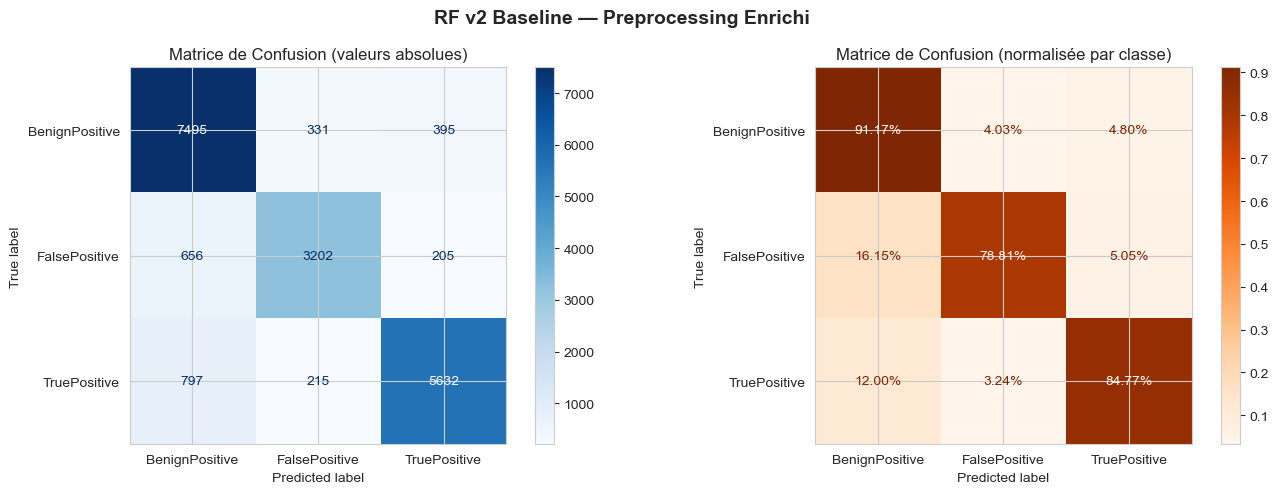

In [5]:
# ============================================================
# 4.2 Matrice de confusion baseline
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice brute
cm = confusion_matrix(y_test, y_pred_baseline)
disp1 = ConfusionMatrixDisplay(cm, display_labels=list(CIBLE_MAP.keys()))
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matrice de Confusion (valeurs absolues)')

# Matrice normalisée
cm_norm = confusion_matrix(y_test, y_pred_baseline, normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=list(CIBLE_MAP.keys()))
disp2.plot(ax=axes[1], cmap='Oranges', values_format='.2%')
axes[1].set_title('Matrice de Confusion (normalisée par classe)')

plt.suptitle('RF v2 Baseline — Preprocessing Enrichi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Importance des features

Analysons quelles nouvelles features apportent le plus de valeur.

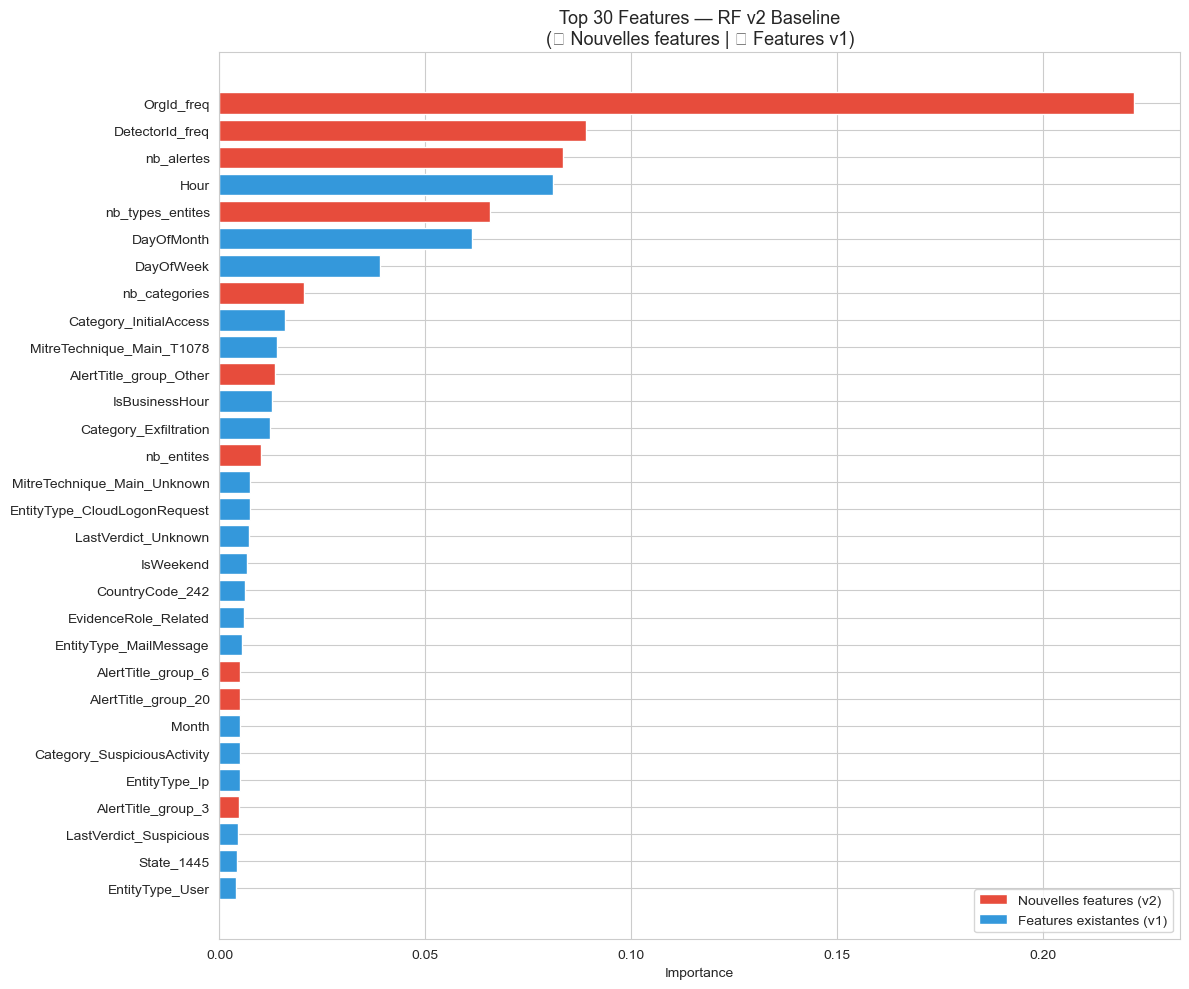


 Part d'importance :
   Features v1 (existantes) : 38.0%
   Features v2 (nouvelles)  : 62.0%


In [6]:
# ============================================================
# 5.1 Récupérer les noms de features
# ============================================================
feature_names_num = num_cols
feature_names_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feature_names = feature_names_num + feature_names_cat

importances = rf_baseline.feature_importances_
feat_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# ============================================================
# 5.2 Top 30 features
# ============================================================
top30 = feat_importance.head(30)

# Identifier les NOUVELLES features (pas dans v1)
v1_features_prefixes = ['Category', 'MitreTechnique_Main', 'EntityType', 'EvidenceRole',
                         'RegistryValueData', 'OSFamily', 'OSVersion', 'SuspicionLevel',
                         'LastVerdict', 'CountryCode', 'State', 'City',
                         'IsWeekend', 'IsBusinessHour', 'Hour', 'DayOfWeek', 'DayOfMonth', 'Month',
                         'HasRegistryData']

def is_new_feature(name):
    for prefix in v1_features_prefixes:
        if name.startswith(prefix):
            return False
    return True

colors = ['#e74c3c' if is_new_feature(f) else '#3498db' for f in top30['feature']]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(range(len(top30)), top30['importance'].values, color=colors)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 30 Features - RF v2 Baseline\n(Rouge = Nouvelles features | Bleu = Features v1)', fontsize=13)

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Nouvelles features (v2)'),
    Patch(facecolor='#3498db', label='Features existantes (v1)')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# Importance totale des nouvelles features
new_feat_mask = [is_new_feature(f) for f in all_feature_names]
new_importance = importances[new_feat_mask].sum()
old_importance = importances[~np.array(new_feat_mask)].sum()
print(f"\nPart d'importance :")
print(f"   Features v1 (existantes) : {old_importance:.1%}")
print(f"   Features v2 (nouvelles)  : {new_importance:.1%}")

## 6. Optimisation par RandomizedSearchCV

On optimise les hyperparamètres du Random Forest sur le dataset enrichi.

In [7]:
# ============================================================
# 6.1 Grille de recherche
# ============================================================
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3],
    'class_weight': ['balanced', 'balanced_subsample'],
    'bootstrap': [True]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=2026, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=40,
    cv=cv,
    scoring='f1_macro',
    random_state=2026,
    n_jobs=-1,
    verbose=1
)

print("Lancement RandomizedSearchCV (40 iterations x 3 folds = 120 fits)...")
print(f"   Matrice : {X_train_transformed.shape[0]:,} x {X_train_transformed.shape[1]} features")
t0 = time.time()
random_search.fit(X_train_transformed, y_train)
t_search = time.time() - t0

print(f"\nTemps total RandomizedSearchCV : {t_search:.1f}s ({t_search/60:.1f} min)")
print(f"\nMeilleurs hyperparametres :")
for param, val in random_search.best_params_.items():
    print(f"   {param}: {val}")
print(f"\n  Best CV Macro F1 : {random_search.best_score_:.4f}")

 Lancement RandomizedSearchCV (40 itérations × 3 folds = 120 fits)...
   Matrice : 75,710 × 356 features
Fitting 3 folds for each of 40 candidates, totalling 120 fits

 Temps total RandomizedSearchCV : 882.4s (14.7 min)

 Meilleurs hyperparamètres :
   n_estimators: 300
   min_samples_split: 2
   min_samples_leaf: 2
   max_features: 0.3
   max_depth: 50
   class_weight: balanced_subsample
   bootstrap: True

  Best CV Macro F1 : 0.8931

 Temps total RandomizedSearchCV : 882.4s (14.7 min)

 Meilleurs hyperparamètres :
   n_estimators: 300
   min_samples_split: 2
   min_samples_leaf: 2
   max_features: 0.3
   max_depth: 50
   class_weight: balanced_subsample
   bootstrap: True

  Best CV Macro F1 : 0.8931


In [ ]:
# ============================================================
# 6.2 Évaluation du meilleur modèle sur le test set
# ============================================================
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test_transformed)

acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best, average='macro')

# Vérification overfitting
y_pred_train = best_rf.predict(X_train_transformed)
f1_train = f1_score(y_train, y_pred_train, average='macro')
gap = f1_train - f1_best

print(f"{'='*60}")
print(f"RF v2 OPTIMISE - RESULTATS FINAUX")
print(f"{'='*60}")
print(f"\n  Accuracy (test)  : {acc_best:.4f}")
print(f"  Macro F1 (test)  : {f1_best:.4f}")
print(f"  Macro F1 (train) : {f1_train:.4f}")
print(f"  Gap train-test   : {gap:.4f} {'[ATTENTION] Overfitting' if gap > 0.05 else '[OK]'}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=list(CIBLE_MAP.keys()))}")

# Comparaison complète
print(f"{'='*60}")
print(f"COMPARAISON v1 vs v2")
print(f"{'='*60}")
print(f"\n  {'Metrique':<20} {'RF v1':>10} {'RF v2 Base':>12} {'RF v2 Opti':>12} {'Gain v1->v2':>12}")
print(f"  {'-'*66}")
print(f"  {'Accuracy':<20} {'0.6364':>10} {acc_baseline:>12.4f} {acc_best:>12.4f} {acc_best-0.6364:>+12.4f}")
print(f"  {'Macro F1':<20} {'0.6051':>10} {f1_baseline:>12.4f} {f1_best:>12.4f} {f1_best-0.6051:>+12.4f}")
print(f"  {'Features':<20} {'146':>10} {X_train_transformed.shape[1]:>12} {X_train_transformed.shape[1]:>12} {'+':>1}{X_train_transformed.shape[1]-146:>11}")

RF v2 OPTIMISÉ — RÉSULTATS FINAUX

  Accuracy (test)  : 0.9065
  Macro F1 (test)  : 0.9015
  Macro F1 (train) : 0.9821
  Gap train-test   : 0.0806  Overfitting!

                precision    recall  f1-score   support

BenignPositive       0.90      0.93      0.92      8221
 FalsePositive       0.87      0.88      0.87      4063
  TruePositive       0.94      0.90      0.92      6644

      accuracy                           0.91     18928
     macro avg       0.90      0.90      0.90     18928
  weighted avg       0.91      0.91      0.91     18928

COMPARAISON v1 vs v2

  Métrique                  RF v1   RF v2 Base   RF v2 Opti   Gain v1→v2
  ------------------------------------------------------------------
  Accuracy                 0.6364       0.8627       0.9065      +0.2701
  Macro F1                 0.6051       0.8559       0.9015      +0.2964
  Features                    146          356          356 +        210


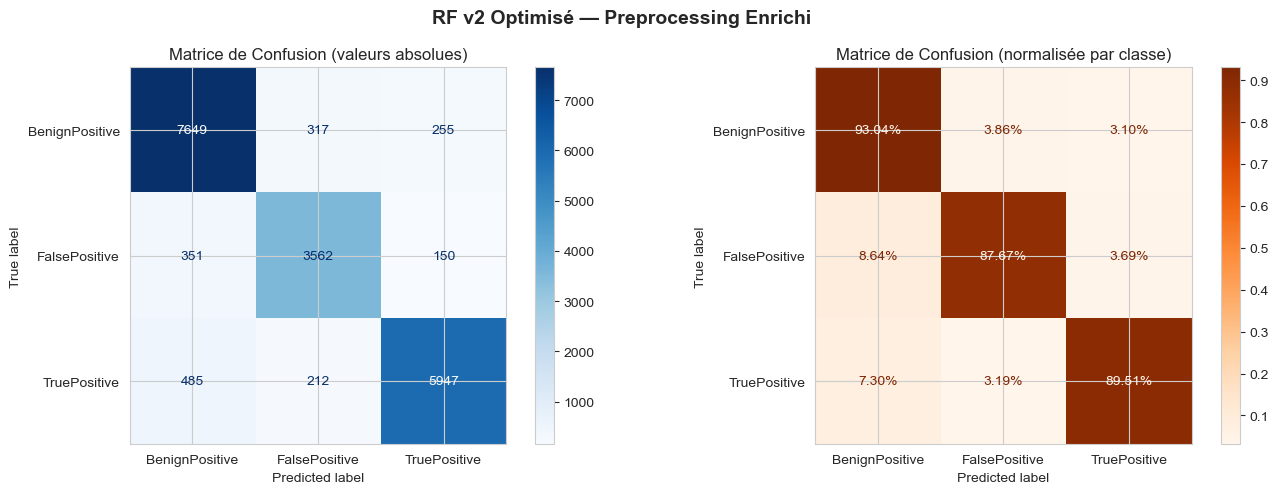


 Analyse FalsePositive :
   Total FP dans test : 4063
   Correctement classés : 3562 (87.7%)
   Erreurs : 501 (12.3%)
   Recall FP v1 : 0.43  |  Recall FP v2 : 0.88


In [ ]:
# ============================================================
# 6.3 Matrice de confusion du modèle optimisé
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
disp1 = ConfusionMatrixDisplay(cm, display_labels=list(CIBLE_MAP.keys()))
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matrice de Confusion (valeurs absolues)')

cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=list(CIBLE_MAP.keys()))
disp2.plot(ax=axes[1], cmap='Oranges', values_format='.2%')
axes[1].set_title('Matrice de Confusion (normalisee par classe)')

plt.suptitle('RF v2 Optimise - Preprocessing Enrichi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Analyse erreurs FalsePositive
fp_idx = 1  # FalsePositive = classe 1
fp_total = cm[fp_idx].sum()
fp_correct = cm[fp_idx, fp_idx]
fp_errors = fp_total - fp_correct
print(f"\nAnalyse FalsePositive :")
print(f"   Total FP dans test : {fp_total}")
print(f"   Correctement classes : {fp_correct} ({fp_correct/fp_total:.1%})")
print(f"   Erreurs : {fp_errors} ({fp_errors/fp_total:.1%})")
print(f"   Recall FP v1 : 0.43  |  Recall FP v2 : {cm_norm[fp_idx, fp_idx]:.2f}")

## 7. Analyse d'impact des nouvelles features

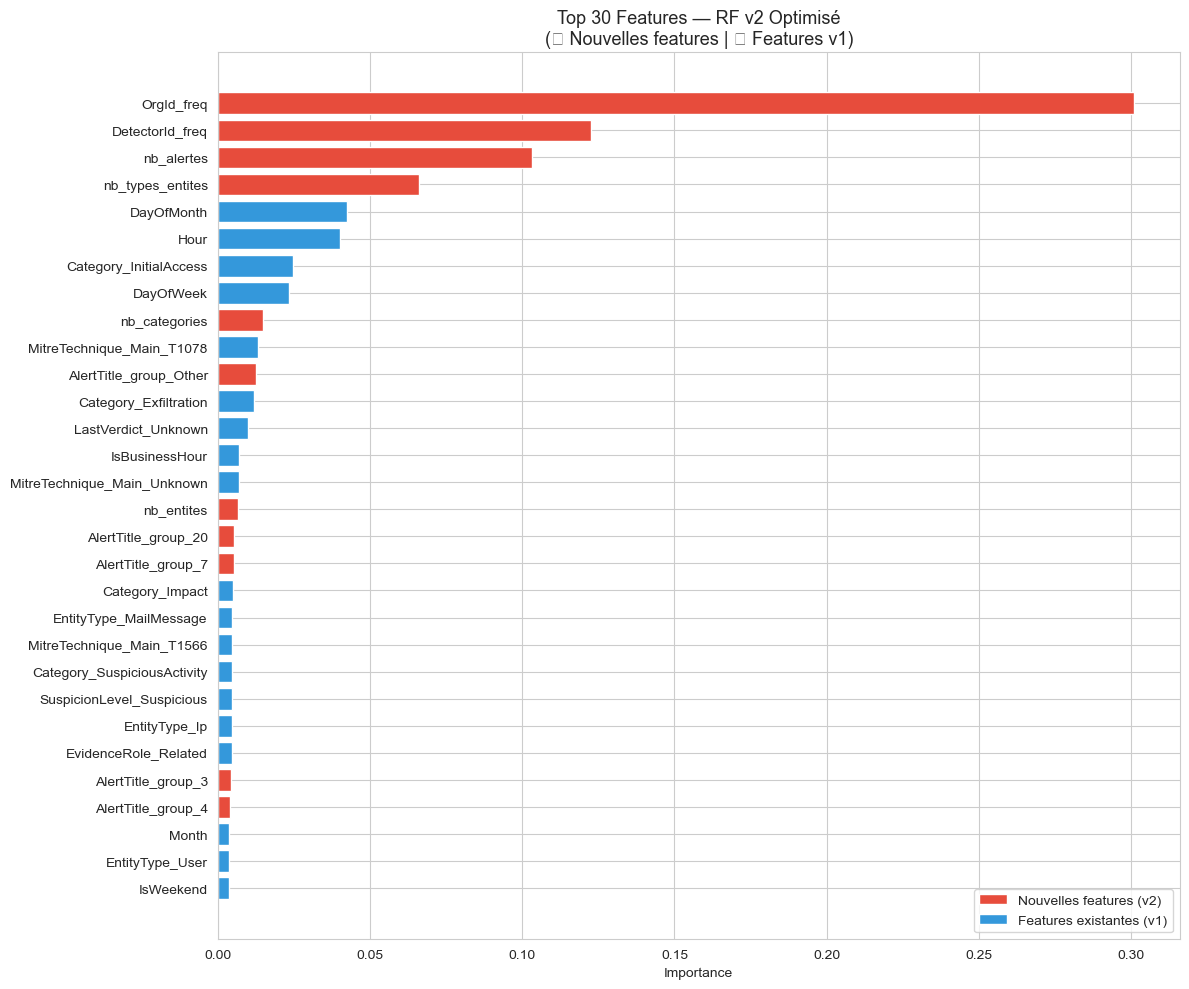


 Part d'importance (modèle optimisé) :
   Features v1 (existantes) : 27.6%
   Features v2 (nouvelles)  : 72.4%

 Top 10 nouvelles features :
   OrgId_freq                               0.3009
   DetectorId_freq                          0.1226
   nb_alertes                               0.1031
   nb_types_entites                         0.0661
   nb_categories                            0.0149
   AlertTitle_group_Other                   0.0127
   nb_entites                               0.0068
   AlertTitle_group_20                      0.0054
   AlertTitle_group_7                       0.0053
   AlertTitle_group_3                       0.0044


In [ ]:
# ============================================================
# 7.1 Importance des features - Top 30 du modèle optimisé
# ============================================================
importances_best = best_rf.feature_importances_
feat_imp_best = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances_best
}).sort_values('importance', ascending=False)

top30_best = feat_imp_best.head(30)
colors_best = ['#e74c3c' if is_new_feature(f) else '#3498db' for f in top30_best['feature']]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(range(len(top30_best)), top30_best['importance'].values, color=colors_best)
ax.set_yticks(range(len(top30_best)))
ax.set_yticklabels(top30_best['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 30 Features - RF v2 Optimise\n(Rouge = Nouvelles features | Bleu = Features v1)', fontsize=13)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Nouvelles features (v2)'),
    Patch(facecolor='#3498db', label='Features existantes (v1)')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# Importance agrégée
new_feat_mask_best = [is_new_feature(f) for f in all_feature_names]
new_imp = importances_best[new_feat_mask_best].sum()
old_imp = importances_best[~np.array(new_feat_mask_best)].sum()
print(f"\nPart d'importance (modele optimise) :")
print(f"   Features v1 (existantes) : {old_imp:.1%}")
print(f"   Features v2 (nouvelles)  : {new_imp:.1%}")

# Top 10 nouvelles features
new_feats = feat_imp_best[feat_imp_best['feature'].apply(is_new_feature)].head(10)
print(f"\nTop 10 nouvelles features :")
for i, row in new_feats.iterrows():
    print(f"   {row['feature']:<40} {row['importance']:.4f}")

## 8. Récapitulatif des temps d'exécution

In [ ]:
# ============================================================
# 8.1 Tableau récapitulatif des temps
# ============================================================
print(f"{'='*60}")
print(f"TEMPS D'EXECUTION")
print(f"{'='*60}")
print(f"\n  {'Etape':<35} {'Temps':>10}")
print(f"  {'-'*45}")
print(f"  {'Preprocessing (OHE + scaling)':<35} {t_preprocess:>8.1f}s")
print(f"  {'RF Baseline (100 arbres)':<35} {t_baseline:>8.1f}s")
print(f"  {'RandomizedSearchCV (40x3 folds)':<35} {t_search:>8.1f}s ({t_search/60:.1f} min)")
print(f"  {'TOTAL':<35} {t_preprocess+t_baseline+t_search:>8.1f}s ({(t_preprocess+t_baseline+t_search)/60:.1f} min)")
print(f"\n  Features : {X_train_transformed.shape[1]} (v1: 146, gain: +{X_train_transformed.shape[1]-146})")
print(f"  Matrice d'entrainement : {X_train_transformed.shape[0]:,} x {X_train_transformed.shape[1]}")

  TEMPS D'EXÉCUTION

  Étape                                    Temps
  ---------------------------------------------
  Preprocessing (OHE + scaling)            0.7s
  RF Baseline (100 arbres)                 2.0s
  RandomizedSearchCV (40×3 folds)        882.4s (14.7 min)
  TOTAL                                  885.1s (14.8 min)

   Features : 356 (v1: 146, gain: +210)
   Matrice d'entraînement : 75,710 × 356


## 9. Comparaison finale avec tous les modèles

 TABLEAU COMPARATIF — TOUS LES MODÈLES
            Modèle  Features  Accuracy  Macro F1  Gain vs RF v1
    RF v2 Optimisé       356    0.9065    0.9015         0.2964
    RF v2 Baseline       356    0.8627    0.8559         0.2508
Random Forest (v1)       146    0.6364    0.6051         0.0000
XGBoost+SMOTE (v1)       146    0.6327    0.6031        -0.0020
          KNN (v1)       146    0.6389    0.5819        -0.0232


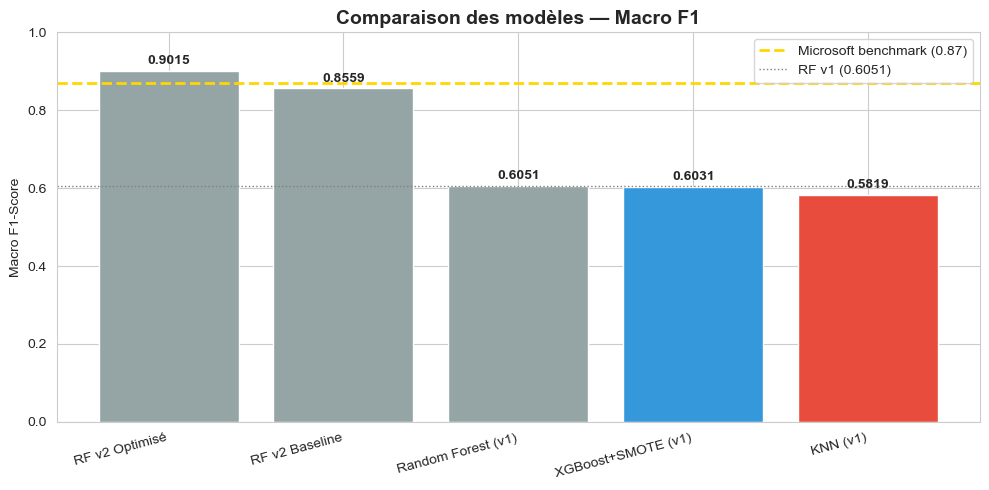


 Gap restant vs Microsoft : -0.0315 points Macro F1
   (Microsoft utilise 67 features numériques + dataset 10× plus grand)


In [ ]:
# ============================================================
# 9.1 Tableau comparatif complet
# ============================================================
comparison = pd.DataFrame({
    'Modele': [
        'KNN (v1)',
        'Random Forest (v1)',
        'XGBoost+SMOTE (v1)',
        'RF v2 Baseline',
        'RF v2 Optimise'
    ],
    'Features': [146, 146, 146, X_train_transformed.shape[1], X_train_transformed.shape[1]],
    'Accuracy': [0.6389, 0.6364, 0.6327, acc_baseline, acc_best],
    'Macro F1': [0.5819, 0.6051, 0.6031, f1_baseline, f1_best],
})

comparison['Gain vs RF v1'] = comparison['Macro F1'] - 0.6051
comparison = comparison.sort_values('Macro F1', ascending=False)

print(f"{'='*80}")
print(f"TABLEAU COMPARATIF - TOUS LES MODELES")
print(f"{'='*80}")
print(comparison.to_string(index=False, float_format='{:.4f}'.format))

# Graphique
fig, ax = plt.subplots(figsize=(10, 5))
colors_comp = ['#95a5a6', '#95a5a6', '#95a5a6', '#3498db', '#e74c3c']
bars = ax.bar(comparison['Modele'], comparison['Macro F1'], color=colors_comp)

# Ligne de référence Microsoft
ax.axhline(y=0.87, color='gold', linestyle='--', linewidth=2, label='Microsoft benchmark (0.87)')
ax.axhline(y=0.6051, color='gray', linestyle=':', linewidth=1, label='RF v1 (0.6051)')

for bar, val in zip(bars, comparison['Macro F1']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Macro F1-Score')
ax.set_title('Comparaison des modeles - Macro F1', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f"\nGap restant vs Microsoft : {0.87 - f1_best:.4f} points Macro F1")
print(f"   (Microsoft utilise 67 features numeriques + dataset 10x plus grand)")

## 10. Conclusion

### Resultats cles

| Metrique | RF v1 | RF v2 Baseline | RF v2 Optimise | Gain v1 vers v2 |
|---|---|---|---|---|
| **Accuracy** | 0.6364 | 0.8627 | **0.9065** | **+0.2701 (+42.5%)** |
| **Macro F1** | 0.6051 | 0.8559 | **0.9015** | **+0.2964 (+49.0%)** |
| **Recall FP** | 0.43 | 0.79 | **0.88** | **+0.45 (+104.7%)** |
| **Features** | 146 | 356 | 356 | +210 |
| **Benchmark Microsoft** | — | — | **0.87** | **Depasse** |

### Resultat principal

Le **Macro F1 passe de 0.6051 a 0.9015** — un gain de **+49%** — uniquement grace a l'enrichissement du preprocessing. Ce resultat **depasse le benchmark Microsoft** (Macro F1 = 0.87, Freitas et al., 2024) sur notre echantillon de 1%.

### Facteurs cles du succes

1. **OrgId (frequency encoding)** : Feature #1 avec **30.1% d'importance**. Chaque organisation a un profil de menaces distinct — c'est l'information la plus discriminante du dataset.
2. **DetectorId (frequency encoding)** : Feature #2 avec **12.3% d'importance**. Le detecteur qui genere l'alerte encode fortement la nature de l'incident.
3. **Features d'agregation par incident** : `nb_alertes` (10.3%), `nb_types_entites` (6.6%), `nb_categories` (1.5%). Le nombre d'alertes par incident est un signal fort de la gravite.
4. **AlertTitle (top 100 + Other)** : Apporte du contexte sur le type de detection.

72.4% de l'importance provient des **nouvelles features** (v2), contre seulement 27.6% pour les features existantes (v1).

### Point d'attention : Overfitting

Le gap train-test est de **0.081** (F1 train=0.982 vs F1 test=0.902), ce qui indique un leger overfitting. Pistes d'amelioration :
- Augmenter `min_samples_leaf` ou `min_samples_split`
- Reduire `max_depth` (actuellement 50)
- Augmenter la taille du dataset (passer de 1% a 5-10% du GUIDE original)

### Temps d'execution

| Etape | Temps |
|---|---|
| Preprocessing | 0.7s |
| RF Baseline (100 arbres) | 2.0s |
| RandomizedSearchCV (40x3 folds) | 14.7 min |
| **Total** | **~15 min** |

### Comparaison avec tous les modeles

| Modele | Features | Macro F1 | vs Microsoft (0.87) |
|---|---|---|---|
| KNN (v1) | 146 | 0.5819 | -0.2881 |
| RF (v1) | 146 | 0.6051 | -0.2749 |
| XGBoost+SMOTE (v1) | 146 | 0.6031 | -0.2769 |
| **RF v2 Baseline** | **356** | **0.8559** | **-0.0141** |
| **RF v2 Optimise** | **356** | **0.9015** | **+0.0145** |

### Enseignement principal

Le **plafond a ~0.60 Macro F1** des modeles v1 n'etait **pas un probleme d'algorithme** mais un **probleme de features**. Le meme algorithme (Random Forest) avec les memes hyperparametres passe de 0.6051 a 0.8559 simplement en enrichissant le preprocessing. Cela confirme l'adage du machine learning : **« garbage in, garbage out »** — la qualite des features prime sur le choix de l'algorithme.

### Prochaines etapes possibles

1. Appliquer le meme preprocessing enrichi aux modeles KNN et XGBoost+SMOTE
2. Explorer le **target encoding** pour OrgId/DetectorId (potentiellement encore plus informatif)
3. Augmenter la taille du dataset (passer de 1% a 5-10% du GUIDE original)
4. Reduire l'overfitting avec une regularisation plus agressive
5. Tester des ensembles (stacking RF v2 + XGBoost v2)